In [1]:
# Modern matplotlib defaults for the whole notebook.

import matplotlib as mpl
import matplotlib.pyplot as plt

# Retina / high-DPI output in notebooks
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats("retina")
except ImportError:
    pass




mpl.rcParams.update({
    # Figure
    "figure.figsize": (7.5, 4.8),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",

    # Font / text
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    # Lines
    "lines.linewidth": 2.0,
    "lines.markersize": 5.5,
    "lines.markeredgewidth": 0.8,

    # Axes
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,

    # Grid
    "grid.alpha": 0.28,
    "grid.linewidth": 0.8,

    # Legend
    "legend.frameon": True,
    "legend.framealpha": 0.9,
    "legend.edgecolor": "0.85",

    # Layout
    "figure.constrained_layout.use": True,
})


def finish_plot(
    *,
    title=None,
    xlabel=None,
    ylabel=None,
    yscale=None,
    legend=True,
    legend_ncol=1,
    legend_loc="best",
):
    """
    Small helper for consistent plot finishing.
    """
    ax = plt.gca()

    if title is not None:
        ax.set_title(title, pad=10)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if yscale is not None:
        ax.set_yscale(yscale)

    ax.minorticks_on()
    ax.grid(True, which="major", alpha=0.30)
    ax.grid(True, which="minor", alpha=0.12)

    if legend:
        ax.legend(
            loc=legend_loc,
            ncol=legend_ncol,
            frameon=True,
            fancybox=True,
        )

    plt.show()

In [2]:
import numpy as np


def random_fssk(
    *,
    q: int,
    R: int,
    m: int,
    d: int,
    seed: int = 0,
    eig_min: float = 0.1,
    eig_max: float = 1.5,
    jordan_alpha: float = 0.25,
    dtype=np.float64,
):
    rng = np.random.default_rng(seed)

    eigs = rng.uniform(eig_min, eig_max, size=R)
    J = np.diag(eigs)

    for i in range(R - 1):
        J[i, i + 1] = jordan_alpha

    G = rng.normal(size=(R, R))
    Q, _ = np.linalg.qr(G)
    Lambda = Q @ J @ Q.T

    A = np.empty((q, m, d), dtype=dtype)

    for p in range(q):
        if m <= d:
            G = rng.normal(size=(d, m))
            Qp, _ = np.linalg.qr(G)
            A[p] = Qp.T
        else:
            G = rng.normal(size=(m, d))
            Qp, _ = np.linalg.qr(G)
            A[p] = Qp

    b = rng.normal(size=(q, R))
    b /= np.sum(np.abs(b), axis=0, keepdims=True)

    return Lambda.astype(dtype), A.astype(dtype), b.astype(dtype)

In [6]:
from tensordev.util.random_paths import unit_speed_paths
# Lambda = 0 validation:
#
# Check that
#
#     SSS_{Lambda=0}(X) == Sig(Y),
#     Y_t = sum_p (sum_r b[p, r]) A[p] X_t
#
# for q = 1 and q > 1, over several truncation levels.
#
# Assumes the following are already defined:
#     - unit_speed_paths(...)
#     - random_fssk(...)

import math
import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

from tensordev import get_default_core
from tensordev.sss import StateSpaceSignature

from tensordev.development import path_signature

JaxCore = get_default_core()


def transformed_lambda0_path(X, A, b):
    """
    X: (B, L, d)
    A: (q, m, d)
    b: (q, R)

    Returns Y: (B, L, m), where
        Y_t = sum_p (sum_r b[p, r]) A[p] X_t.
    """
    c = jnp.sum(b, axis=1)                 # (q,)
    M = jnp.einsum("p,pmd->md", c, A)      # (m, d)
    return jnp.einsum("md,bld->blm", M, X)


def compare_levelwise(sig_a, sig_b):
    rows = []

    for n, (Sa, Sb) in enumerate(zip(sig_a, sig_b)):
        err = np.asarray(jnp.abs(Sa - Sb))
        fac = math.factorial(n)

        rows.append(
            {
                "level": n,
                "mean_abs": float(err.mean()),
                "max_abs": float(err.max()),
                "mean_scaled": float(fac * err.mean()),
                "max_scaled": float(fac * err.max()),
            }
        )

    return rows


def lambda0_validation_case(
    *,
    q,
    R,
    m,
    d,
    N_max=10,
    n_paths=8,
    dt=1 / 64,
    dt_fine=1 / 4096,
    seed=0,
):
    # Random normalized parameters, then overwrite Lambda by zero.
    _, A_np, b_np = random_fssk(
        q=q,
        R=R,
        m=m,
        d=d,
        seed=seed,
    )

    Lambda = jnp.zeros((R, R), dtype=jnp.float64)
    A = jnp.asarray(A_np, dtype=jnp.float64)
    b = jnp.asarray(b_np, dtype=jnp.float64)

    X = jnp.asarray(
        unit_speed_paths(
            dt=dt,
            dt_fine=dt_fine,
            n_paths=n_paths,
            dim=d,
            seed=10_000 + seed,
            dtype=np.float64,
        )
    )

    Y = transformed_lambda0_path(X, A, b)

    rows = []

    for N in range(1, N_max + 1):
        sss = StateSpaceSignature.from_matrix(
            Lambda=Lambda,
            A=A,
            b=b,
            trunc=N,
        )

        S_sss = sss.vsig(X, dt=dt, axis=-2)
        S_sig = path_signature(Y, trunc=N, axis=-2)

        for row in compare_levelwise(S_sss, S_sig):
            row.update(
                {
                    "q": q,
                    "R": R,
                    "m": m,
                    "d": d,
                    "N": N,
                }
            )
            rows.append(row)

    return pd.DataFrame(rows)


# --- Run q = 1 and q > 1 cases ---------------------------------------------

df_lam0 = pd.concat(
    [
        lambda0_validation_case(q=1, R=1, m=2, d=2, N_max=10, seed=0),
        lambda0_validation_case(q=3, R=2, m=2, d=2, N_max=10, seed=1),
        lambda0_validation_case(q=3, R=3, m=3, d=3, N_max=8, seed=2),
    ],
    ignore_index=True,
)

# Compact summary: worst error per setup and truncation.
df_lam0_summary = (
    df_lam0
    .groupby(["q", "R", "m", "d", "N"], as_index=False)
    .agg(
        max_abs=("max_abs", "max"),
        max_scaled=("max_scaled", "max"),
        mean_abs=("mean_abs", "max"),
        mean_scaled=("mean_scaled", "max"),
    )
)

#display(df_lam0_summary)

print("Overall max_abs:   ", df_lam0["max_abs"].max())
print("Overall max_scaled:", df_lam0["max_scaled"].max())
print("float64 eps:       ", np.finfo(np.float64).eps)

Overall max_abs:    1.7763568394002505e-15
Overall max_scaled: 4.094015165941045e-15
float64 eps:        2.220446049250313e-16


In [ ]:
# Run the timing benchmark and load results.

import subprocess, sys
from pathlib import Path
import pandas as pd

RUN_REGIME = "HOME"   # "HOME" or "SERVER"

SCRIPT   = Path("run_timings.py").resolve()
WORK_DIR = SCRIPT.parent

cmd = [sys.executable, str(SCRIPT), "--regime", RUN_REGIME]
print("Running:", " ".join(cmd))
result = subprocess.run(cmd, cwd=str(WORK_DIR))

if result.returncode != 0:
    raise RuntimeError(f"run_timings.py exited with code {result.returncode}")

IN_PKL = WORK_DIR / "validation_outputs" / f"fssk_exact_scaling_timings_{RUN_REGIME.lower()}.pkl"
df_timings = pd.read_pickle(IN_PKL)
print(f"\nLoaded {len(df_timings)} rows from {IN_PKL.name}")
display(df_timings.head())
display(df_timings.groupby(["family", "design"]).size().rename("n_runs").reset_index())


Running: /Users/paulhager/PycharmProjects/levyMMD/.conda/bin/python /Users/paulhager/PycharmProjects/levyMMD/tensordev/notebooks/sss/run_timings.py --regime HOME
Regime          : HOME
n_repeats       : 2
Total runs      : 221

family  design
q1      J_ext       4
        N_ext       3
        R_ext       4
        cube       36
qgt1    J_ext      24
        N_ext      18
        R_ext      24
        cube      108

[001/221]  qgt1 |  cube | q=2  J=64  R=1  N=4
[002/221]  qgt1 |  cube | q=2  J=64  R=1  N=5
[003/221]  qgt1 |  cube | q=2  J=64  R=1  N=6
[004/221]  qgt1 |  cube | q=2  J=64  R=2  N=4
[005/221]  qgt1 |  cube | q=2  J=64  R=2  N=5
[006/221]  qgt1 |  cube | q=2  J=64  R=2  N=6
[007/221]  qgt1 |  cube | q=2  J=64  R=3  N=4
[008/221]  qgt1 |  cube | q=2  J=64  R=3  N=5
[009/221]  qgt1 |  cube | q=2  J=64  R=3  N=6
[010/221]  qgt1 |  cube | q=2  J=128  R=1  N=4
[011/221]  qgt1 |  cube | q=2  J=128  R=1  N=5
[012/221]  qgt1 |  cube | q=2  J=128  R=1  N=6
[013/221]  qgt1 |  cube |

In [9]:
# ============================================================
# Cell 2: load timings, evaluate fixed-slope scaling model, plot
# ============================================================
#
# We fix the theoretical slopes and fit only multiplicative constants.
#
# q > 1:
#
#   T ≈ C_q · J · R^2 · N · m^N
#
# so
#
#   log T - log(J R^2 N m^N) ≈ log C_q.
#
# q = 1:
#
#   T ≈ C · J · R^2 · m^N
#
# so
#
#   log T - log(J R^2 m^N) ≈ log C.
#
# This avoids unstable exponent fitting and directly checks whether the
# theoretical cost proxy explains the measured hot runtimes up to constants.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------------
# Load
# ---------------------------------------------------------------------------

RUN_REGIME = "HOME"      # "HOME" or "SERVER"

OUTPUT_DIR = Path("validation_outputs")
IN_PKL = OUTPUT_DIR / f"fssk_exact_scaling_timings_{RUN_REGIME.lower()}.pkl"

df_timings = pd.read_pickle(IN_PKL)

print("Loaded:", IN_PKL)
display(df_timings.head())
display(df_timings.groupby(["family", "design"]).size().rename("n_runs").reset_index())


# ---------------------------------------------------------------------------
# Plot helper fallback
# ---------------------------------------------------------------------------

def finish_or_fallback(
    *,
    title,
    xlabel,
    ylabel,
    xscale=None,
    yscale=None,
    legend=True,
    legend_ncol=1,
):
    ax = plt.gca()

    if xscale is not None:
        ax.set_xscale(xscale)
    if yscale is not None:
        ax.set_yscale(yscale)

    if "finish_plot" in globals():
        finish_plot(
            title=title,
            xlabel=xlabel,
            ylabel=ylabel,
            yscale=yscale,
            legend=legend,
            legend_ncol=legend_ncol,
        )
    else:
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.grid(True, which="both", alpha=0.3)
        if legend:
            ax.legend(ncol=legend_ncol)
        plt.show()


# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------

def log_r2(y, yhat):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)

    rss = float(np.sum((y - yhat) ** 2))
    tss = float(np.sum((y - y.mean()) ** 2))

    if tss == 0:
        return np.nan

    return 1.0 - rss / tss


def fixed_model_summary(df, *, group_col="fixed_model"):
    rows = []

    for name, g in df.groupby(group_col):
        rows.append(
            dict(
                fixed_model=name,
                n=len(g),
                r2_log=log_r2(g["log_hot_time"], g["pred_log_hot_time_fixed"]),
                mean_abs_log_resid=float(np.mean(np.abs(g["fixed_resid_log"]))),
                max_abs_log_resid=float(np.max(np.abs(g["fixed_resid_log"]))),
                mean_abs_rel_error=float(np.mean(np.abs(g["fixed_rel_error"]))),
                max_abs_rel_error=float(np.max(np.abs(g["fixed_rel_error"]))),
            )
        )

    return pd.DataFrame(rows)


# ---------------------------------------------------------------------------
# Prepare data
# ---------------------------------------------------------------------------

df = df_timings.copy()

# Prefer median timing if available; otherwise use mean timing.
TIME_COL = "hot_time_median" if "hot_time_median" in df.columns else "hot_time_mean"

df = df[
    np.isfinite(df[TIME_COL])
    & (df[TIME_COL] > 0)
].copy()

df["runtime"] = df[TIME_COL]
df["log_hot_time"] = np.log(df["runtime"])

# Use J directly, not J - 1.
df["log_J"] = np.log(df["J"])

# Use 2 log(R), so the R^2 scaling has coefficient one.
df["two_log_R"] = 2.0 * np.log(df["R"])

# Truncation terms.
df["log_mN"] = df["N"] * np.log(df["m"])
df["log_NmN"] = np.log(df["N"]) + df["log_mN"]

# Full theoretical log-cost proxies.
df["log_cost_q1"] = df["log_J"] + df["two_log_R"] + df["log_mN"]
df["log_cost_qgt1"] = df["log_J"] + df["two_log_R"] + df["log_NmN"]

df["cost_q1"] = np.exp(df["log_cost_q1"])
df["cost_qgt1"] = np.exp(df["log_cost_qgt1"])

m_values = sorted(df["m"].unique())
assert len(m_values) == 1, m_values
m = m_values[0]

df_qgt1 = df[df["family"] == "qgt1"].copy()
df_q1 = df[df["family"] == "q1"].copy()

print("Using runtime column:", TIME_COL)
print()
print("Fixed q > 1 model:")
print("  T ≈ C_q · J · R^2 · N · m^N")
print()
print("Fixed q = 1 model:")
print("  T ≈ C · J · R^2 · m^N")


# ---------------------------------------------------------------------------
# Fit constants only
# ---------------------------------------------------------------------------

# q = 1: one global constant.
df_q1["log_constant_estimate"] = (
    df_q1["log_hot_time"] - df_q1["log_cost_q1"]
)

q1_log_C = float(df_q1["log_constant_estimate"].mean())
q1_C = float(np.exp(q1_log_C))

df_q1["log_C"] = q1_log_C
df_q1["C"] = q1_C
df_q1["pred_log_hot_time_fixed"] = df_q1["log_C"] + df_q1["log_cost_q1"]
df_q1["pred_hot_time_fixed"] = np.exp(df_q1["pred_log_hot_time_fixed"])
df_q1["fixed_resid_log"] = df_q1["log_hot_time"] - df_q1["pred_log_hot_time_fixed"]
df_q1["fixed_rel_error"] = df_q1["pred_hot_time_fixed"] / df_q1["runtime"] - 1.0
df_q1["fixed_model"] = "q1_fixed_slopes"


# q > 1: one constant per q.
df_qgt1["log_constant_estimate"] = (
    df_qgt1["log_hot_time"] - df_qgt1["log_cost_qgt1"]
)

df_q_constants = (
    df_qgt1
    .groupby("q", as_index=False)
    .agg(
        log_C=("log_constant_estimate", "mean"),
        log_C_std=("log_constant_estimate", "std"),
        n=("log_constant_estimate", "count"),
    )
)

df_q_constants["C"] = np.exp(df_q_constants["log_C"])
df_q_constants["C_std_factor"] = np.exp(df_q_constants["log_C_std"])
df_q_constants["relative_C"] = df_q_constants["C"] / df_q_constants["C"].iloc[0]

df_qgt1 = df_qgt1.merge(
    df_q_constants[["q", "log_C", "C"]],
    on="q",
    how="left",
)

df_qgt1["pred_log_hot_time_fixed"] = df_qgt1["log_C"] + df_qgt1["log_cost_qgt1"]
df_qgt1["pred_hot_time_fixed"] = np.exp(df_qgt1["pred_log_hot_time_fixed"])
df_qgt1["fixed_resid_log"] = df_qgt1["log_hot_time"] - df_qgt1["pred_log_hot_time_fixed"]
df_qgt1["fixed_rel_error"] = df_qgt1["pred_hot_time_fixed"] / df_qgt1["runtime"] - 1.0
df_qgt1["fixed_model"] = "qgt1_fixed_slopes"


df_fixed_all = pd.concat(
    [df_qgt1, df_q1],
    ignore_index=True,
)

print("q = 1 fitted constant C:", q1_C)
print("q > 1 fitted constants:")
display(df_q_constants)


# ---------------------------------------------------------------------------
# Evaluation summaries
# ---------------------------------------------------------------------------

df_fixed_summary = fixed_model_summary(df_fixed_all)

display(df_fixed_summary)

df_resid_summary = (
    df_fixed_all
    .assign(abs_log_resid=lambda x: np.abs(x["fixed_resid_log"]))
    .groupby(["family", "design"], as_index=False)
    .agg(
        n=("run_id", "count"),
        mean_abs_log_resid=("abs_log_resid", "mean"),
        max_abs_log_resid=("abs_log_resid", "max"),
        mean_abs_rel_error=("fixed_rel_error", lambda x: float(np.mean(np.abs(x)))),
        max_abs_rel_error=("fixed_rel_error", lambda x: float(np.max(np.abs(x)))),
    )
)

display(df_resid_summary)

df_time_summary = (
    df
    .groupby(["family", "design"], as_index=False)
    .agg(
        n=("run_id", "count"),
        mean_construct_time=("construct_time", "mean"),
        mean_first_call_time=("first_call_time", "mean"),
        mean_hot_time=("runtime", "mean"),
        median_hot_time=("runtime", "median"),
        max_hot_time=("runtime", "max"),
    )
)

display(df_time_summary)


# ---------------------------------------------------------------------------
# Additional diagnostics: constants by design
# ---------------------------------------------------------------------------

df_constant_by_design = (
    df_fixed_all
    .groupby(["family", "design", "q"], as_index=False)
    .agg(
        mean_log_constant=("log_constant_estimate", "mean"),
        std_log_constant=("log_constant_estimate", "std"),
        n=("log_constant_estimate", "count"),
    )
)

df_constant_by_design["constant"] = np.exp(df_constant_by_design["mean_log_constant"])

display(df_constant_by_design)


# ---------------------------------------------------------------------------
# Plots
# ---------------------------------------------------------------------------

# 1. Predicted vs measured.
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=False, sharey=False)

for ax, g_all, title in [
    (
        axes[0],
        df_qgt1,
        rf"$q>1$: fixed slopes, q-specific constants, $R^2={log_r2(df_qgt1['log_hot_time'], df_qgt1['pred_log_hot_time_fixed']):.4f}$",
    ),
    (
        axes[1],
        df_q1,
        rf"$q=1$: fixed slopes, single constant, $R^2={log_r2(df_q1['log_hot_time'], df_q1['pred_log_hot_time_fixed']):.4f}$",
    ),
]:
    for design, marker in [("cube", "o"), ("J_ext", "s"), ("R_ext", "^"), ("N_ext", "D")]:
        g = g_all[g_all["design"] == design]
        if len(g) == 0:
            continue

        ax.scatter(
            g["runtime"],
            g["pred_hot_time_fixed"],
            marker=marker,
            alpha=0.75,
            label=design,
        )

    lo = min(g_all["runtime"].min(), g_all["pred_hot_time_fixed"].min())
    hi = max(g_all["runtime"].max(), g_all["pred_hot_time_fixed"].max())

    ax.plot([lo, hi], [lo, hi], linestyle="--", color="black", linewidth=1.2)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(title)
    ax.set_xlabel("measured hot runtime [s]")
    ax.set_ylabel("predicted hot runtime [s]")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(fontsize=8)

fig.suptitle("Fixed-slope scaling model: predicted vs measured")
plt.tight_layout()
plt.show()


# 2. q-dependent constants for q > 1.
plt.figure(figsize=(7.5, 4.8))

plt.plot(
    df_q_constants["q"],
    df_q_constants["relative_C"],
    marker="o",
)

finish_or_fallback(
    title=r"Fitted constants in fixed-slope model for $q>1$",
    xlabel="q",
    ylabel="constant relative to q=2",
    yscale="log",
    legend=False,
)


# 3. Log-constant estimates by q and design.
plt.figure(figsize=(8.5, 5))

for design, marker in [("cube", "o"), ("J_ext", "s"), ("R_ext", "^"), ("N_ext", "D")]:
    g = df_qgt1[df_qgt1["design"] == design]
    if len(g) == 0:
        continue

    plt.scatter(
        g["q"],
        g["log_constant_estimate"],
        marker=marker,
        alpha=0.65,
        label=design,
    )

for _, row in df_q_constants.iterrows():
    plt.hlines(
        row["log_C"],
        xmin=row["q"] - 0.35,
        xmax=row["q"] + 0.35,
        color="black",
        linewidth=1.2,
    )

finish_or_fallback(
    title=r"$q>1$: log-constant estimates after theoretical normalization",
    xlabel="q",
    ylabel=r"$\log T - \log(JR^2Nm^N)$",
    legend=True,
    legend_ncol=2,
)


# 4. Residuals by family and design.
plt.figure(figsize=(8.5, 5))

for (family, design), g in df_fixed_all.groupby(["family", "design"]):
    x = np.full(len(g), f"{family}\n{design}")
    plt.scatter(
        x,
        g["fixed_resid_log"],
        alpha=0.7,
        label=f"{family} {design}",
    )

plt.axhline(0.0, linestyle="--", color="black", linewidth=1.0)

finish_or_fallback(
    title="Fixed-slope model residuals",
    xlabel=None,
    ylabel="log-runtime residual",
    legend=False,
)


# 5. Axial extension raw curves for q > 1.
for design in ["J_ext", "R_ext", "N_ext"]:
    varied = {"J_ext": "J", "R_ext": "R", "N_ext": "N"}[design]
    df_d = df_qgt1[df_qgt1["design"] == design]

    if len(df_d) == 0:
        continue

    plt.figure(figsize=(8.5, 5))

    for q, g in df_d.groupby("q"):
        g = g.sort_values(varied)
        plt.plot(
            g[varied],
            g["runtime"],
            marker="o",
            label=f"q={q}",
        )

    finish_or_fallback(
        title=rf"$q>1$ axial extension: runtime vs {varied}",
        xlabel=varied,
        ylabel="hot runtime [s]",
        xscale="log" if varied in ("J", "R") else None,
        yscale="log",
        legend=True,
        legend_ncol=2,
    )


# 6. q = 1 axial extension raw curves.
for design in ["J_ext", "R_ext", "N_ext"]:
    varied = {"J_ext": "J", "R_ext": "R", "N_ext": "N"}[design]
    df_d = df_q1[df_q1["design"] == design]

    if len(df_d) == 0:
        continue

    plt.figure(figsize=(7.5, 4.8))

    g = df_d.sort_values(varied)
    plt.plot(
        g[varied],
        g["runtime"],
        marker="o",
        label="q=1",
    )

    finish_or_fallback(
        title=rf"$q=1$ axial extension: runtime vs {varied}",
        xlabel=varied,
        ylabel="hot runtime [s]",
        xscale="log" if varied in ("J", "R") else None,
        yscale="log",
        legend=True,
    )


# 7. Normalized runtime diagnostics.
df_norm = df_fixed_all.copy()
df_norm["norm_q1"] = df_norm["runtime"] / df_norm["cost_q1"]
df_norm["norm_qgt1"] = df_norm["runtime"] / df_norm["cost_qgt1"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

g1 = df_norm[df_norm["family"] == "q1"]
axes[0].scatter(g1["N"], g1["norm_q1"], alpha=0.7)
axes[0].axhline(q1_C, linestyle="--", color="black", linewidth=1.2, label="fitted constant")
axes[0].set_title(r"$q=1$: $T / (J R^2 m^N)$")
axes[0].set_xlabel("N")
axes[0].set_ylabel("normalized runtime")
axes[0].set_yscale("log")
axes[0].grid(True, which="both", alpha=0.25)
axes[0].legend(fontsize=8)

g2 = df_norm[df_norm["family"] == "qgt1"]
for q, g in g2.groupby("q"):
    axes[1].scatter(g["N"], g["norm_qgt1"], alpha=0.7, label=f"q={q}")

for _, row in df_q_constants.iterrows():
    axes[1].axhline(row["C"], linestyle="--", linewidth=0.9, alpha=0.4)

axes[1].set_title(r"$q>1$: $T / (J R^2 N m^N)$")
axes[1].set_xlabel("N")
axes[1].set_yscale("log")
axes[1].grid(True, which="both", alpha=0.25)
axes[1].legend(ncol=2, fontsize=8)

fig.suptitle("Normalized hot-runtime diagnostics")
plt.tight_layout()
plt.show()


# 8. Construction / first-call / hot-time decomposition.
df_time_bar = (
    df
    .groupby("family", as_index=False)
    .agg(
        construct_time=("construct_time", "median"),
        first_call_time=("first_call_time", "median"),
        hot_time=("runtime", "median"),
    )
)

x = np.arange(len(df_time_bar))
width = 0.25

plt.figure(figsize=(7.5, 4.8))

plt.bar(
    x - width,
    df_time_bar["construct_time"],
    width,
    label="construction",
)

plt.bar(
    x,
    df_time_bar["first_call_time"],
    width,
    label="first call",
)

plt.bar(
    x + width,
    df_time_bar["hot_time"],
    width,
    label="hot execution",
)

plt.xticks(x, df_time_bar["family"])

finish_or_fallback(
    title="Median timing decomposition by family",
    xlabel=None,
    ylabel="time [s]",
    yscale="log",
    legend=True,
)


# ---------------------------------------------------------------------------
# Compact printout
# ---------------------------------------------------------------------------

print()
print("Selected regime:", RUN_REGIME)
print("Using runtime column:", TIME_COL)

print()
print("Fixed-slope q > 1 model")
print("  Theory: T ≈ C_q · J · R^2 · N · m^N")
print("  log-space R²:", log_r2(df_qgt1["log_hot_time"], df_qgt1["pred_log_hot_time_fixed"]))
print("  mean |log residual|:", float(np.mean(np.abs(df_qgt1["fixed_resid_log"]))))
print("  max  |log residual|:", float(np.max(np.abs(df_qgt1["fixed_resid_log"]))))

print()
print("Fixed-slope q = 1 model")
print("  Theory: T ≈ C · J · R^2 · m^N")
print("  fitted C:", q1_C)
print("  log-space R²:", log_r2(df_q1["log_hot_time"], df_q1["pred_log_hot_time_fixed"]))
print("  mean |log residual|:", float(np.mean(np.abs(df_q1["fixed_resid_log"]))))
print("  max  |log residual|:", float(np.max(np.abs(df_q1["fixed_resid_log"]))))

Loaded: validation_outputs/fssk_exact_scaling_timings_home.pkl


,run_id,regime,family,design,q,J,intervals,R,m,d,N,n_paths,n_repeats,construct_time,first_call_time,hot_time_median,hot_time_mean,hot_time_std,q1_proxy,qgt1_proxy
0,0,HOME,qgt1,cube,2,64,63,1,2,2,4,2,2,0.142505,0.257588,0.000454,0.000454,0.000004,1008,4032
1,1,HOME,qgt1,cube,2,64,63,1,2,2,5,2,2,0.017222,0.333160,0.000636,0.000636,0.000025,2016,10080
2,2,HOME,qgt1,cube,2,64,63,1,2,2,6,2,2,0.021328,0.452498,0.001201,0.001201,0.000008,4032,24192
3,3,HOME,qgt1,cube,2,64,63,2,2,2,4,2,2,0.121472,0.263463,0.002004,0.002004,0.000070,4032,16128
4,4,HOME,qgt1,cube,2,64,63,2,2,2,5,2,2,0.015628,0.335233,0.002631,0.002631,0.000033,8064,40320


,family,design,n_runs
0,q1,J_ext,4
1,q1,N_ext,3
2,q1,R_ext,4
3,q1,cube,36
4,qgt1,J_ext,24
5,qgt1,N_ext,18
6,qgt1,R_ext,24
7,qgt1,cube,108


Using runtime column: hot_time_median
q=1 theory cost:   J R^2 m^N
q>1 theory cost:   J R^2 N m^N


,run_id,regime,family,design,q,J,intervals,R,m,d,...,hot_time_mean,hot_time_std,q1_proxy,qgt1_proxy,runtime,theory_cost_q1,theory_cost_qgt1,theory_cost,normalized_runtime,log_normalized_runtime
0,0,HOME,qgt1,cube,2,64,63,1,2,2,...,0.000454,0.000004,1008,4032,0.000454,1024,4096,4096,1.107942e-07,-16.015591
1,1,HOME,qgt1,cube,2,64,63,1,2,2,...,0.000636,0.000025,2016,10080,0.000636,2048,10240,10240,6.212769e-08,-16.594074
2,2,HOME,qgt1,cube,2,64,63,1,2,2,...,0.001201,0.000008,4032,24192,0.001201,4096,24576,24576,4.885693e-08,-16.834370
3,3,HOME,qgt1,cube,2,64,63,2,2,2,...,0.002004,0.000070,4032,16128,0.002004,4096,16384,16384,1.223132e-07,-15.916681
4,4,HOME,qgt1,cube,2,64,63,2,2,2,...,0.002631,0.000033,8064,40320,0.002631,8192,40960,40960,6.422576e-08,-16.560861


,family,design,n,median_norm,mean_norm,std_log_norm,min_norm,max_norm,median_runtime,max_runtime
0,q1,J_ext,4,8.135107e-08,8.238008e-08,0.032701,8.041636e-08,8.640184e-08,0.006901,0.010540
1,q1,N_ext,3,2.516667e-08,2.636422e-08,0.400057,1.671791e-08,3.720808e-08,0.008765,0.009754
2,q1,R_ext,4,2.631381e-08,2.747859e-08,0.136916,2.423091e-08,3.305583e-08,0.005335,0.009925
3,q1,cube,36,6.157900e-08,9.118100e-08,0.710042,2.035070e-08,5.335045e-07,0.001534,0.008741
4,qgt1,J_ext,24,7.574781e-07,1.260454e-06,1.400623,6.313214e-08,3.662396e-06,0.278116,2.400188
5,qgt1,N_ext,18,5.152844e-07,1.246720e-06,1.858836,1.879792e-08,4.462568e-06,0.479947,10.454123
6,qgt1,R_ext,24,2.555782e-07,4.545762e-07,1.395770,2.088138e-08,1.584502e-06,0.260998,2.121998
7,qgt1,cube,108,2.341299e-07,3.570104e-07,1.031682,2.631757e-08,1.645461e-06,0.015063,0.493490


,q,n,log_constant_mean,log_constant_std,constant_median,constant_mean,relative_constant
0,2,38,-16.810731,0.502380,5.565728e-08,5.621926e-08,1.000000
1,3,38,-15.794324,0.374436,1.499059e-07,1.473148e-07,2.693375
2,4,38,-14.972886,0.329665,3.052004e-07,3.308514e-07,5.483566
3,5,38,-14.053764,0.349268,8.779112e-07,8.321420e-07,15.773520
4,6,11,-13.414380,0.480352,1.999290e-06,1.638659e-06,35.921446
5,7,11,-12.877612,0.589719,3.606954e-06,2.927775e-06,64.806500


AttributeError: 'DataFrame' object has no attribute 'to_frame'

In [14]:
# ---------------------------------------------------------------------------
# Part 2: individual scaling fits with matched cube + extension values only
# ---------------------------------------------------------------------------

def matched_axis_data(df, *, family, q, direction):
    """
    Select axial-extension rows plus only those cube rows with the same
    non-varied parameters.

    J direction:
        vary J, match R,N

    R2 direction:
        vary R, match J,N

    truncation direction:
        vary N, match J,R
    """
    if direction == "J":
        ext_design = "J_ext"
        fixed_cols = ["R", "N"]
    elif direction == "R2":
        ext_design = "R_ext"
        fixed_cols = ["J", "N"]
    elif direction == "truncation":
        ext_design = "N_ext"
        fixed_cols = ["J", "R"]
    else:
        raise ValueError(direction)

    if family == "qgt1":
        base = df[(df["family"] == family) & (df["q"] == q)]
    else:
        base = df[df["family"] == family]

    ext = base[base["design"] == ext_design].copy()

    if len(ext) == 0:
        return ext

    # The axial extension should have fixed non-varied parameters.
    fixed_values = {
        col: ext[col].iloc[0]
        for col in fixed_cols
    }

    cube = base[base["design"] == "cube"].copy()

    for col, val in fixed_values.items():
        cube = cube[cube[col] == val]

    out = pd.concat([cube, ext], ignore_index=True)
    out = out.drop_duplicates(["family", "q", "J", "R", "N"], keep="first")

    return out


direction_specs = [
    dict(
        direction="J",
        x_col="log_J",
        x_label=r"$\log J$",
        y_qgt1=lambda x: x["log_runtime"] - x["two_log_R"] - x["log_NmN"],
        y_q1=lambda x: x["log_runtime"] - x["two_log_R"] - x["log_mN"],
        y_label_qgt1=r"$\log(T/(R^2 N m^N))$",
        y_label_q1=r"$\log(T/(R^2 m^N))$",
    ),
    dict(
        direction="R2",
        x_col="two_log_R",
        x_label=r"$2\log R$",
        y_qgt1=lambda x: x["log_runtime"] - x["log_J"] - x["log_NmN"],
        y_q1=lambda x: x["log_runtime"] - x["log_J"] - x["log_mN"],
        y_label_qgt1=r"$\log(T/(J N m^N))$",
        y_label_q1=r"$\log(T/(J m^N))$",
    ),
    dict(
        direction="truncation",
        x_col_qgt1="log_NmN",
        x_col_q1="log_mN",
        x_label_qgt1=r"$\log(Nm^N)$",
        x_label_q1=r"$\log(m^N)$",
        y_qgt1=lambda x: x["log_runtime"] - x["log_J"] - x["two_log_R"],
        y_q1=lambda x: x["log_runtime"] - x["log_J"] - x["two_log_R"],
        y_label_qgt1=r"$\log(T/(J R^2))$",
        y_label_q1=r"$\log(T/(J R^2))$",
    ),
]

fit_rows = []
fit_parts = []

for family in ["qgt1", "q1"]:
    q_values = sorted(df[df["family"] == family]["q"].unique()) if family == "qgt1" else [1]

    for spec in direction_specs:
        direction = spec["direction"]

        for q in q_values:
            g0 = matched_axis_data(
                df,
                family=family,
                q=q,
                direction=direction,
            ).copy()

            if len(g0) < 2:
                continue

            if direction == "truncation":
                if family == "qgt1":
                    x_col = spec["x_col_qgt1"]
                    x_label = spec["x_label_qgt1"]
                else:
                    x_col = spec["x_col_q1"]
                    x_label = spec["x_label_q1"]
            else:
                x_col = spec["x_col"]
                x_label = spec["x_label"]

            if family == "qgt1":
                g0["partial_log_runtime"] = spec["y_qgt1"](g0)
                y_label = spec["y_label_qgt1"]
            else:
                g0["partial_log_runtime"] = spec["y_q1"](g0)
                y_label = spec["y_label_q1"]

            g_fit, fit_info = fit_curve_group(
                g0,
                x_col=x_col,
                y_col="partial_log_runtime",
            )

            g_fit["fit_family"] = family
            g_fit["fit_q"] = q
            g_fit["fit_direction"] = direction
            g_fit["fit_x_col"] = x_col
            g_fit["fit_x_label"] = x_label
            g_fit["fit_y_label"] = y_label

            fit_rows.append(
                dict(
                    family=family,
                    q=q,
                    direction=direction,
                    x_col=x_col,
                    x_label=x_label,
                    y_label=y_label,
                    expected_slope=1.0,
                    slope=fit_info["slope"],
                    slope_error=fit_info["slope"] - 1.0,
                    intercept=fit_info["intercept"],
                    r2=fit_info["r2"],
                    n=fit_info["n"],
                    n_cube=int((g_fit["design"] == "cube").sum()),
                    n_ext=int((g_fit["design"] != "cube").sum()),
                    mean_abs_resid=fit_info["mean_abs_resid"],
                    max_abs_resid=fit_info["max_abs_resid"],
                )
            )

            fit_parts.append(g_fit)

df_individual_fits = pd.DataFrame(fit_rows)
df_individual_pred = pd.concat(fit_parts, ignore_index=True)

print("Individual scaling fits using matched cube + axial extension points:")
display(df_individual_fits)

display(
    df_individual_fits.pivot_table(
        index=["family", "q"],
        columns="direction",
        values="slope",
    ).reset_index()
)

Individual scaling fits using matched cube + axial extension points:


,family,q,direction,x_col,x_label,y_label,expected_slope,slope,slope_error,intercept,r2,n,n_cube,n_ext,mean_abs_resid,max_abs_resid
0,qgt1,2,J,log_J,$\log J$,$\log(T/(R^2 N m^N))$,1.0,1.024085,0.024085,-16.681232,0.999193,7,3,4,0.021418,0.049519
1,qgt1,3,J,log_J,$\log J$,$\log(T/(R^2 N m^N))$,1.0,1.021665,0.021665,-15.574195,0.978931,7,3,4,0.095252,0.333383
2,qgt1,4,J,log_J,$\log J$,$\log(T/(R^2 N m^N))$,1.0,0.994771,-0.005229,-14.558199,0.999753,7,3,4,0.011768,0.027762
3,qgt1,5,J,log_J,$\log J$,$\log(T/(R^2 N m^N))$,1.0,1.005782,0.005782,-13.797142,0.999606,7,3,4,0.013070,0.042325
4,qgt1,6,J,log_J,$\log J$,$\log(T/(R^2 N m^N))$,1.0,0.997022,-0.002978,-13.025981,0.999993,4,0,4,0.000812,0.001623
5,qgt1,7,J,log_J,$\log J$,$\log(T/(R^2 N m^N))$,1.0,1.009992,0.009992,-12.594289,0.999655,4,0,4,0.005752,0.011504
6,qgt1,2,R2,two_log_R,$2\log R$,$\log(T/(J N m^N))$,1.0,0.712400,-0.287600,-16.363651,0.992682,7,3,4,0.072412,0.184923
7,qgt1,3,R2,two_log_R,$2\log R$,$\log(T/(J N m^N))$,1.0,0.751648,-0.248352,-15.458962,0.984847,7,3,4,0.107068,0.283296
8,qgt1,4,R2,two_log_R,$2\log R$,$\log(T/(J N m^N))$,1.0,0.791849,-0.208151,-14.730953,0.968080,7,3,4,0.161817,0.433191
9,qgt1,5,R2,two_log_R,$2\log R$,$\log(T/(J N m^N))$,1.0,0.729707,-0.270293,-13.707827,0.982775,7,3,4,0.096938,0.316864


direction,family,q,J,R2,truncation
0,q1,1,0.794493,0.634118,0.526016
1,qgt1,2,1.024085,0.712400,0.594403
2,qgt1,3,1.021665,0.751648,0.726729
3,qgt1,4,0.994771,0.791849,0.788889
4,qgt1,5,1.005782,0.729707,0.924410
5,qgt1,6,0.997022,0.891574,1.062006
6,qgt1,7,1.009992,0.712860,1.088029


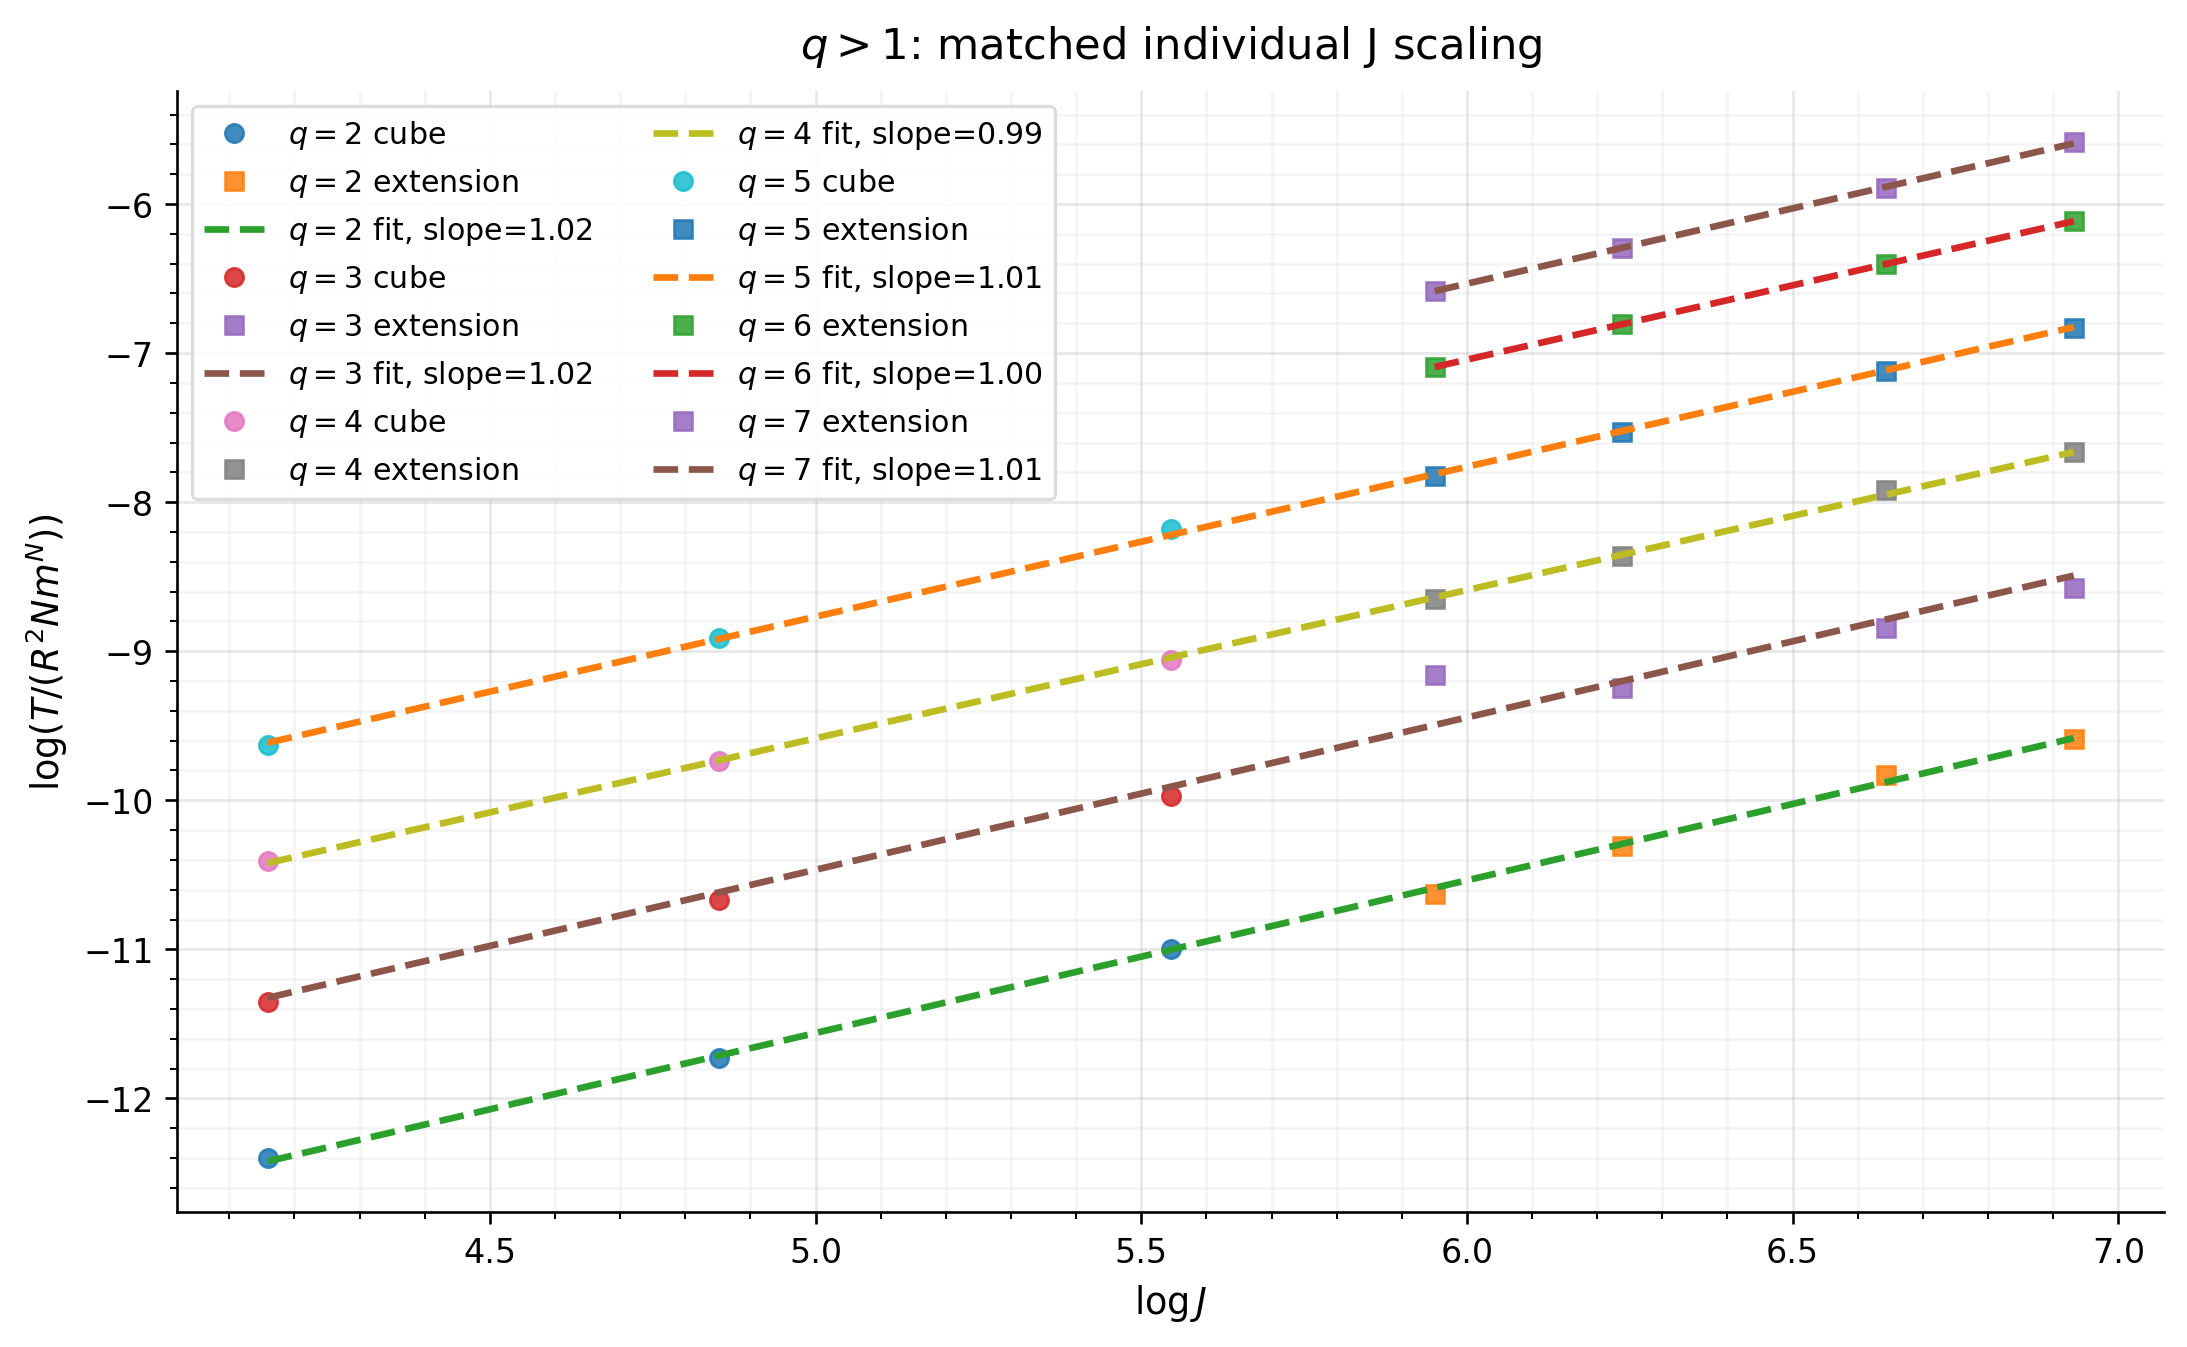

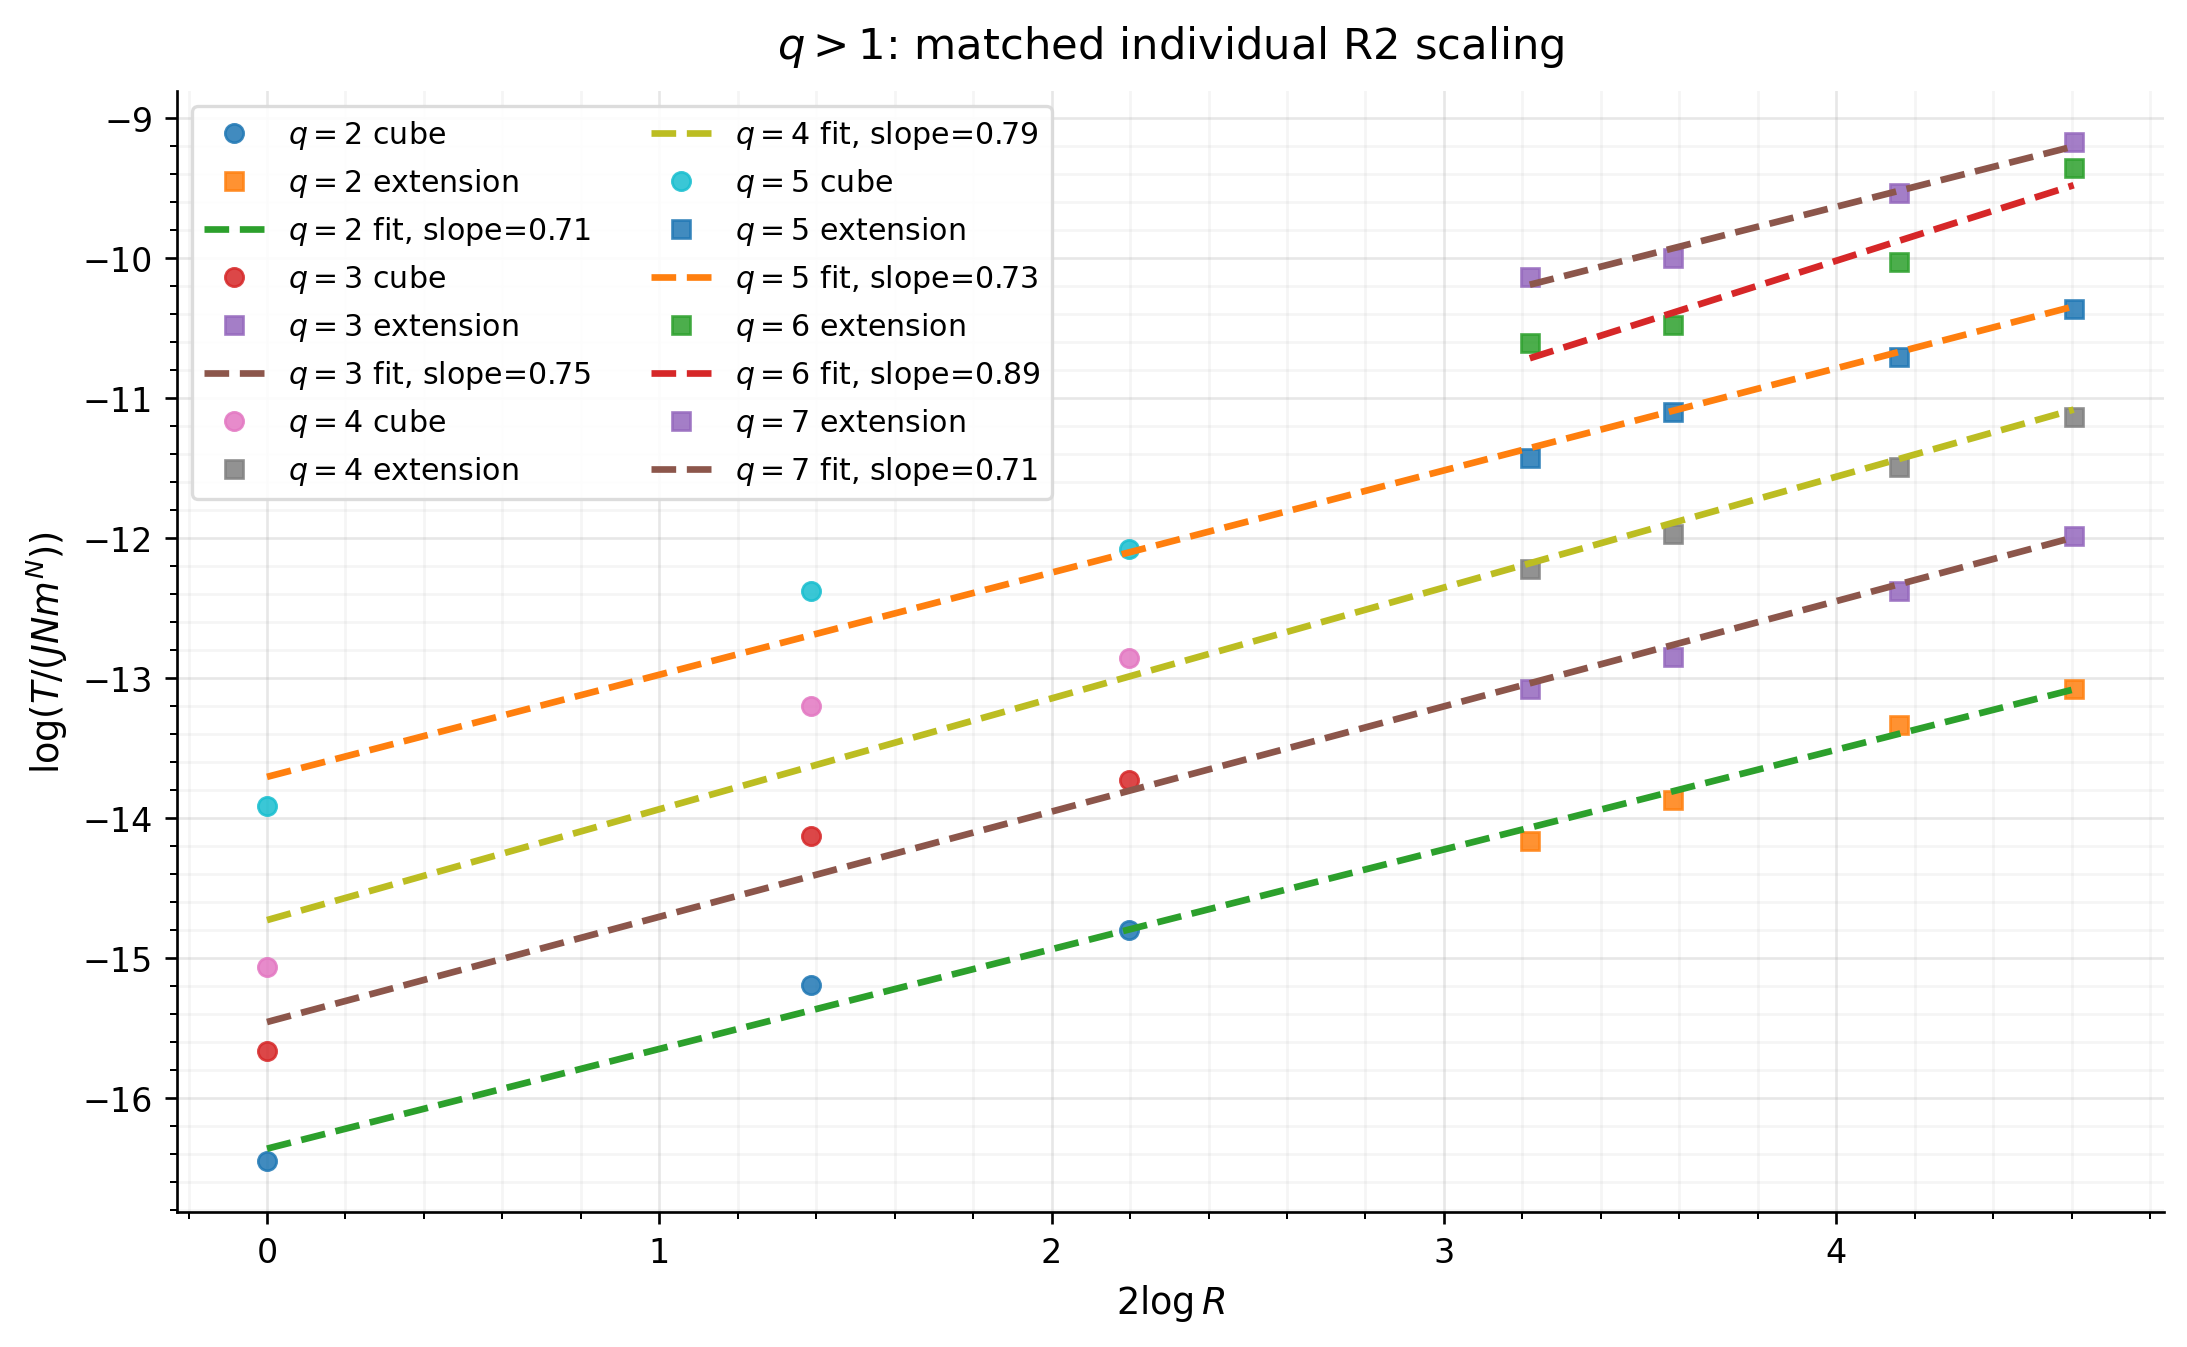

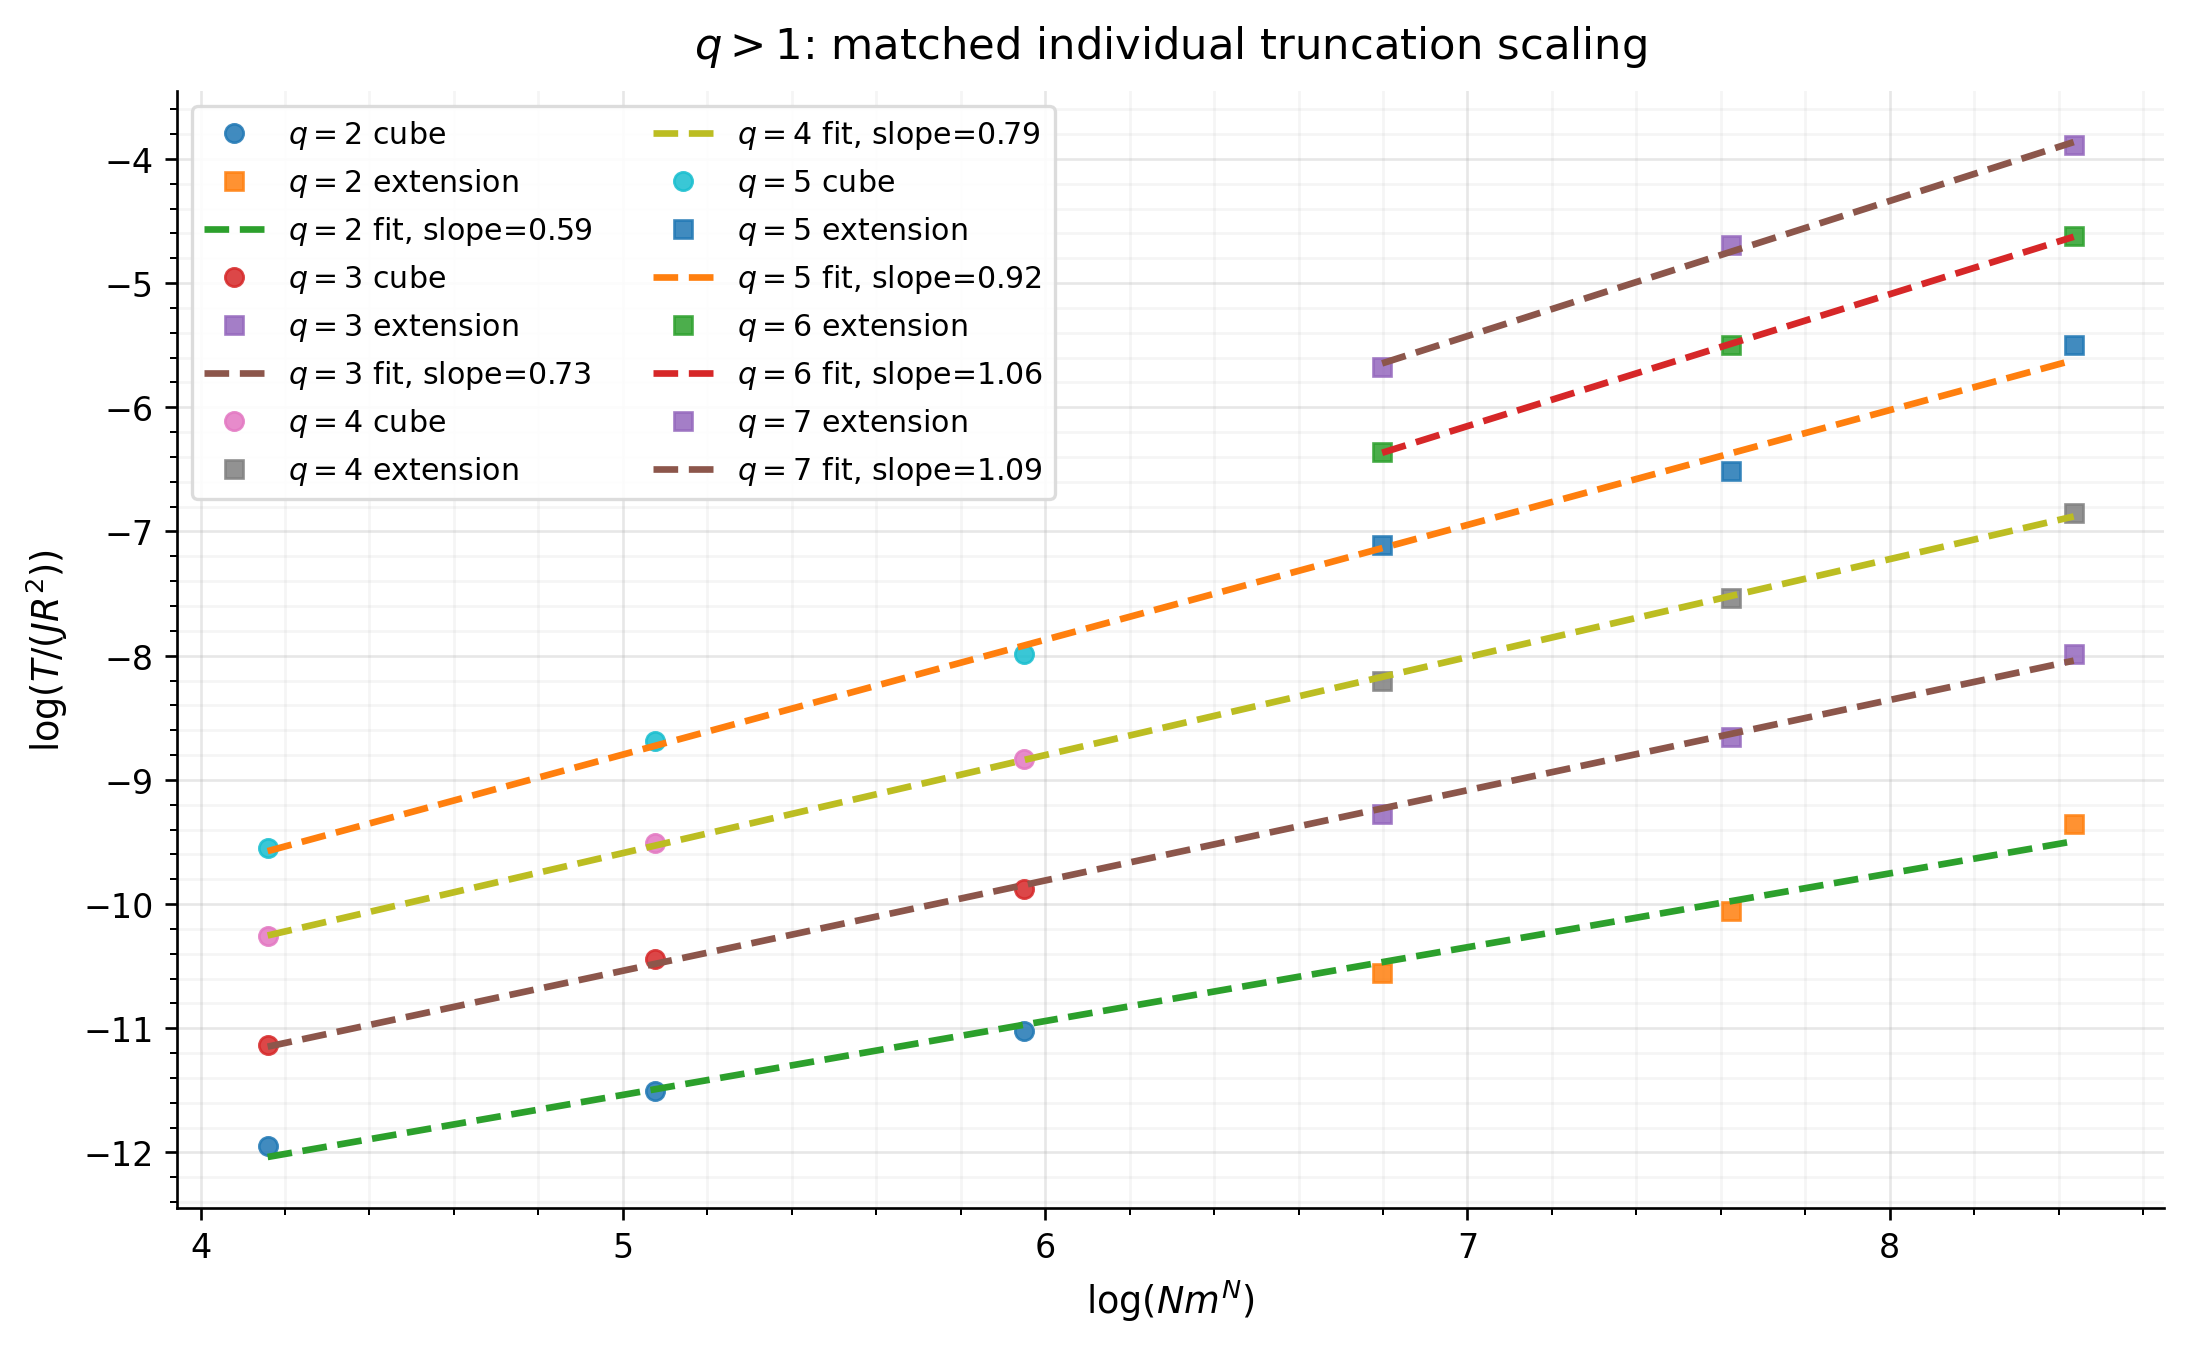

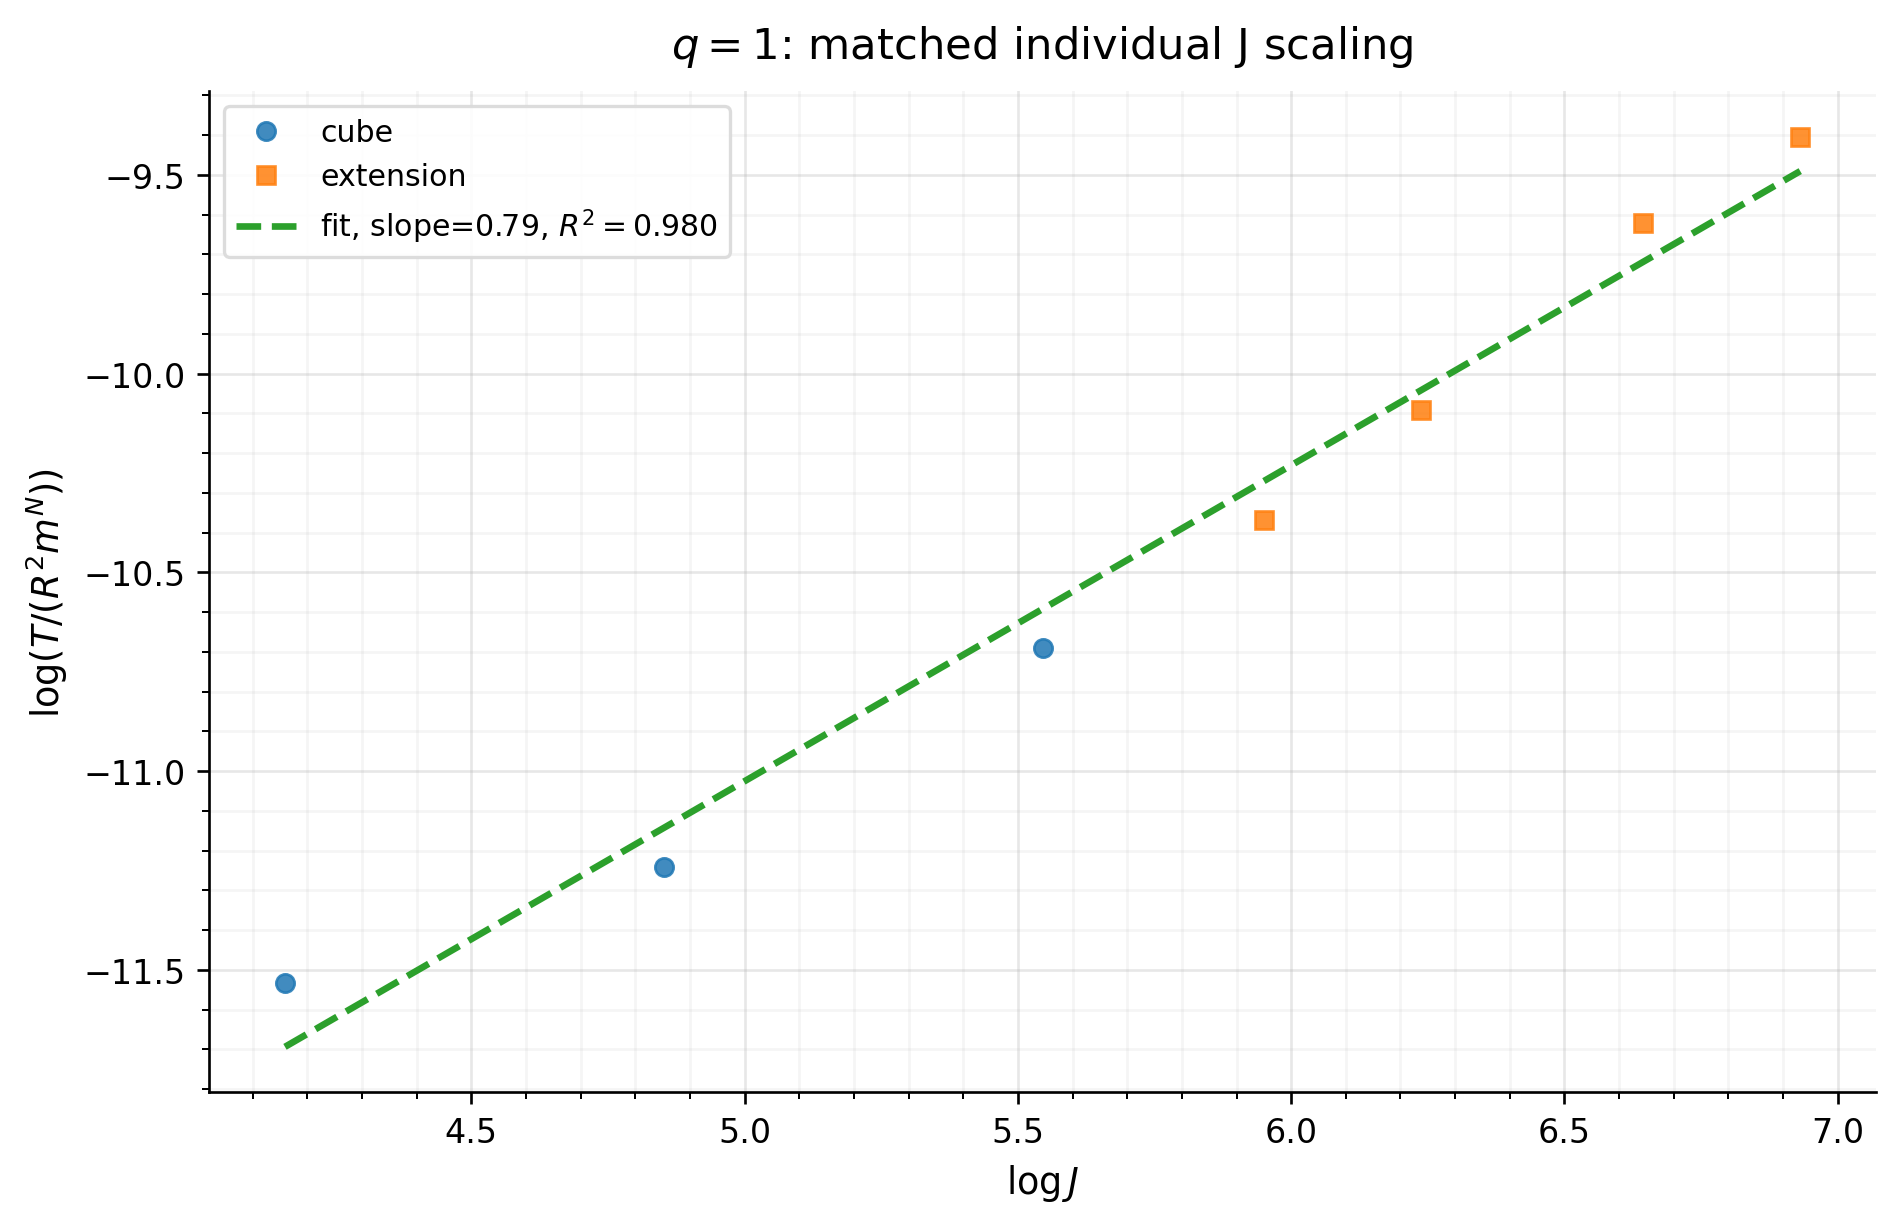

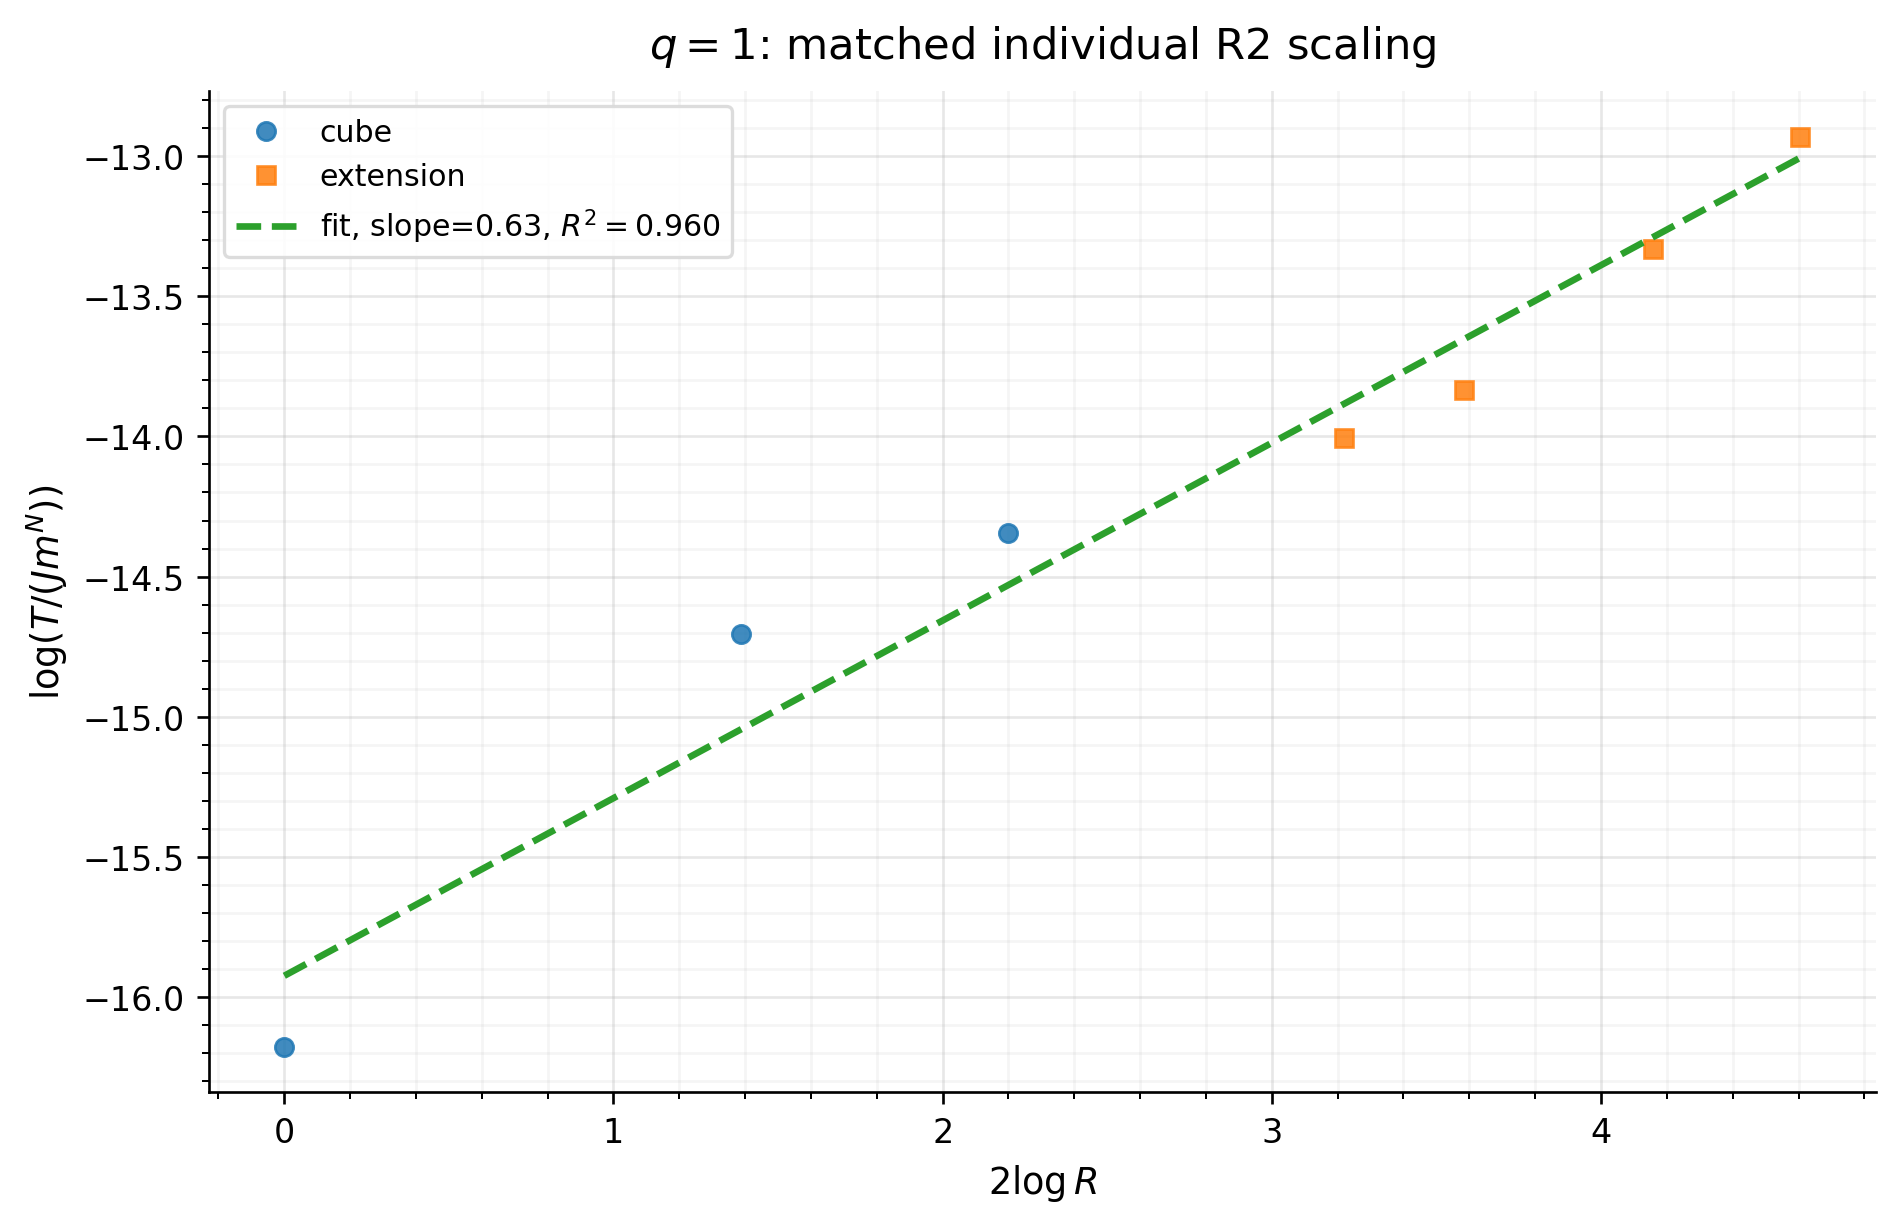

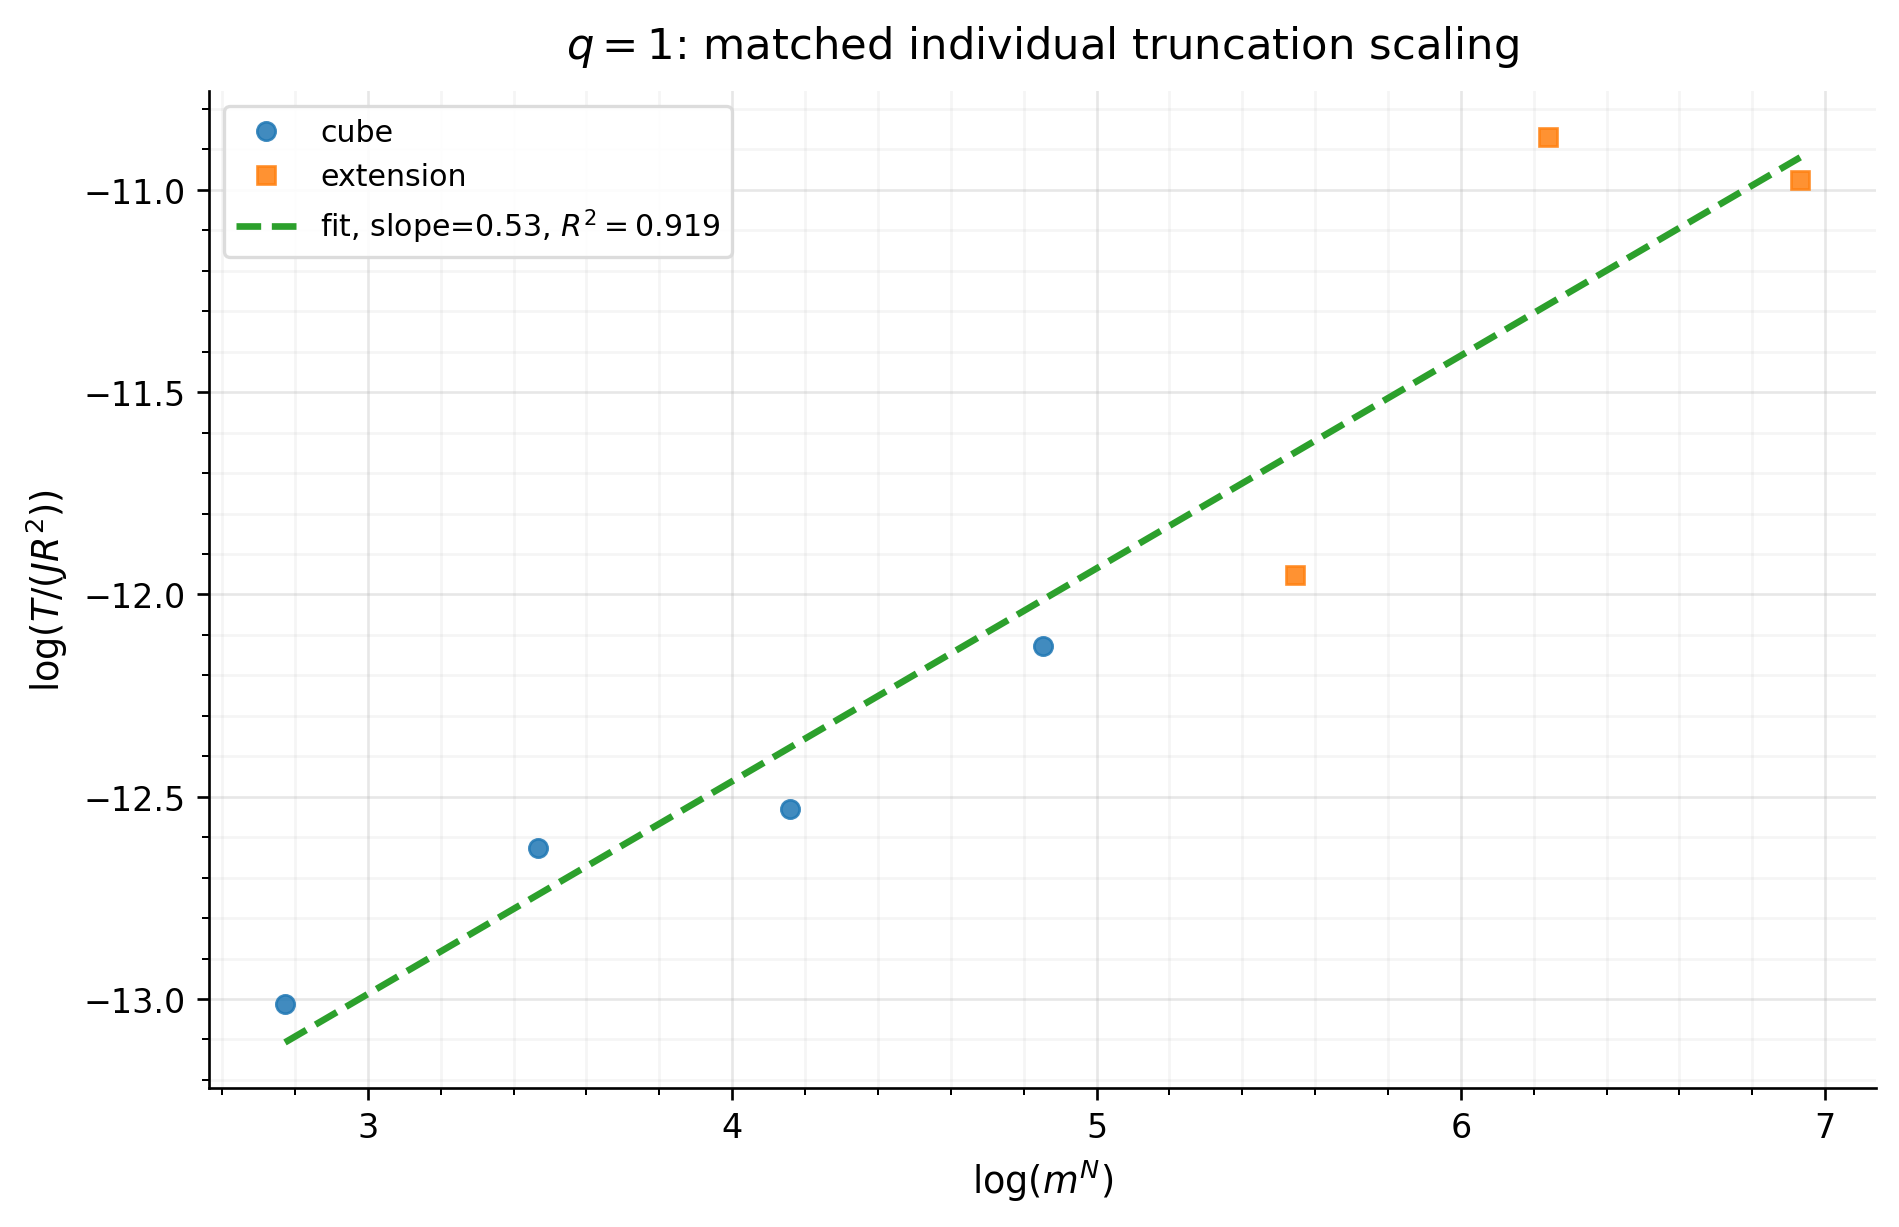

In [15]:
# ---------------------------------------------------------------------------
# Plot B: individual curve fits, q > 1
# ---------------------------------------------------------------------------

for direction in ["J", "R2", "truncation"]:
    df_d = df_individual_pred[
        (df_individual_pred["fit_family"] == "qgt1")
        & (df_individual_pred["fit_direction"] == direction)
    ]

    if len(df_d) == 0:
        continue

    x_col = df_d["fit_x_col"].iloc[0]
    x_label = df_d["fit_x_label"].iloc[0]
    y_label = df_d["fit_y_label"].iloc[0]

    plt.figure(figsize=(9, 5.5))

    for q, g in df_d.groupby("fit_q"):
        g = g.sort_values(x_col)

        fit_row = df_individual_fits[
            (df_individual_fits["family"] == "qgt1")
            & (df_individual_fits["q"] == q)
            & (df_individual_fits["direction"] == direction)
        ].iloc[0]

        g_cube = g[g["design"] == "cube"]
        g_ext = g[g["design"] != "cube"]

        if len(g_cube):
            plt.plot(
                g_cube[x_col],
                g_cube["partial_log_runtime"],
                marker="o",
                linestyle="",
                alpha=0.85,
                label=rf"$q={q}$ cube",
            )

        if len(g_ext):
            plt.plot(
                g_ext[x_col],
                g_ext["partial_log_runtime"],
                marker="s",
                linestyle="",
                alpha=0.85,
                label=rf"$q={q}$ extension",
            )

        x_line = np.linspace(g[x_col].min(), g[x_col].max(), 100)
        y_line = fit_row["intercept"] + fit_row["slope"] * x_line

        plt.plot(
            x_line,
            y_line,
            linestyle="--",
            label=rf"$q={q}$ fit, slope={fit_row['slope']:.2f}",
        )

    finish_or_fallback(
        title=rf"$q>1$: matched individual {direction} scaling",
        xlabel=x_label,
        ylabel=y_label,
        legend=True,
        legend_ncol=2,
    )


# ---------------------------------------------------------------------------
# Plot C: individual curve fits, q = 1
# ---------------------------------------------------------------------------

for direction in ["J", "R2", "truncation"]:
    df_d = df_individual_pred[
        (df_individual_pred["fit_family"] == "q1")
        & (df_individual_pred["fit_direction"] == direction)
    ]

    if len(df_d) == 0:
        continue

    x_col = df_d["fit_x_col"].iloc[0]
    x_label = df_d["fit_x_label"].iloc[0]
    y_label = df_d["fit_y_label"].iloc[0]

    g = df_d.sort_values(x_col)

    fit_row = df_individual_fits[
        (df_individual_fits["family"] == "q1")
        & (df_individual_fits["direction"] == direction)
    ].iloc[0]

    plt.figure(figsize=(7.8, 5.0))

    g_cube = g[g["design"] == "cube"]
    g_ext = g[g["design"] != "cube"]

    if len(g_cube):
        plt.plot(
            g_cube[x_col],
            g_cube["partial_log_runtime"],
            marker="o",
            linestyle="",
            alpha=0.85,
            label="cube",
        )

    if len(g_ext):
        plt.plot(
            g_ext[x_col],
            g_ext["partial_log_runtime"],
            marker="s",
            linestyle="",
            alpha=0.85,
            label="extension",
        )

    x_line = np.linspace(g[x_col].min(), g[x_col].max(), 100)
    y_line = fit_row["intercept"] + fit_row["slope"] * x_line

    plt.plot(
        x_line,
        y_line,
        linestyle="--",
        label=rf"fit, slope={fit_row['slope']:.2f}, $R^2={fit_row['r2']:.3f}$",
    )

    finish_or_fallback(
        title=rf"$q=1$: matched individual {direction} scaling",
        xlabel=x_label,
        ylabel=y_label,
        legend=True,
    )